# Conditional VAE on Fashion-MNIST

## Install

```bash
python3 -m venv venv
source venv/bin/activate
pip install torch torchvision matplotlib
```

## Setup

In [7]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

RUN_TRAINING = True  # set False to load checkpoint and skip training
CHECKPOINT_PATH = "./checkpoints/cvae_fashion_mnist.pt"

IMAGE_DIM = 28 * 28
NUM_CLASSES = 10
LATENT_DIM = 20
HIDDEN_DIM = 400
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3

CLASS_NAMES = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

mps


## Data

In [8]:
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(len(train_data), len(test_data))

60000 10000


## Model

In [9]:
def labels_to_onehot(labels):
    # Converts class ids into vectors that can be concatenated with image or latent data.
    return F.one_hot(labels, NUM_CLASSES).float()


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder input is a flattened 28x28 image plus the class label vector.
        self.encoder = nn.Sequential(
            nn.Linear(IMAGE_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )

        # The encoder outputs the parameters of a Gaussian latent distribution.
        self.mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)

        # Decoder input is a sampled latent vector plus the same kind of label vector.
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, IMAGE_DIM),
            nn.Sigmoid(),
        )

    def encode(self, x, y):
        # Condition the encoder by appending the label to each image vector.
        h = self.encoder(torch.cat([x, y], dim=1))
        return self.mu(h), self.logvar(h)

    def sample(self, mu, logvar):
        # Draw z from the encoded Gaussian using mu plus scaled random noise.
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, y):
        # Condition generation by appending the label to each latent vector.
        return self.decoder(torch.cat([z, y], dim=1))

    def forward(self, x, y):
        # Full CVAE pass: encode distribution, sample z, decode reconstruction.
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar


def save_checkpoint(path, model, optimizer=None, losses=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
            "losses": losses,
            "config": {
                "IMAGE_DIM": IMAGE_DIM,
                "NUM_CLASSES": NUM_CLASSES,
                "LATENT_DIM": LATENT_DIM,
                "HIDDEN_DIM": HIDDEN_DIM,
            },
        },
        path,
    )
    print(f"saved checkpoint to {path}")


def load_checkpoint(path, model, optimizer=None):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and checkpoint.get("optimizer_state_dict"):
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"loaded checkpoint from {path}")
    return checkpoint


model = CVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print(sum(p.numel() for p in model.parameters()))

losses = []
if not RUN_TRAINING:
    checkpoint = load_checkpoint(CHECKPOINT_PATH, model, optimizer)
    losses = checkpoint.get("losses") or []

981624


## Train

epoch 1: 285.55
epoch 2: 251.50
epoch 3: 246.34
epoch 4: 243.77
epoch 5: 242.05
epoch 6: 240.89
epoch 7: 239.98
epoch 8: 239.18
epoch 9: 238.47
epoch 10: 237.99
saved checkpoint to ./checkpoints/cvae_fashion_mnist.pt


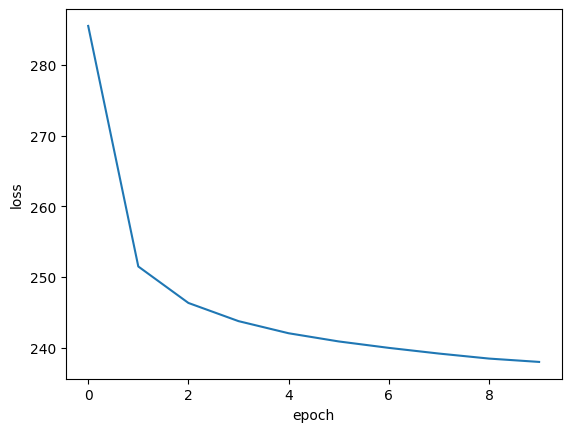

In [10]:
def loss_fn(recon, x, mu, logvar):
    # Reconstruction term compares output pixels to input pixels.
    bce = F.binary_cross_entropy(recon, x, reduction="sum")

    # KL term keeps the encoded latent distribution close to a standard normal.
    kld = -0.5 * torch.sum(1 + logvar - mu.square() - logvar.exp())
    return bce + kld


if RUN_TRAINING:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x, labels in train_loader:
            # Images are flattened and labels are converted before entering the CVAE.
            x = x.view(x.size(0), -1).to(device)
            y = labels_to_onehot(labels).to(device)

            # Forward pass returns the reconstruction and latent distribution parameters.
            recon, mu, logvar = model(x, y)
            loss = loss_fn(recon, x, mu, logvar)

            # Gradients are reset, computed from the loss, then applied by Adam.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_data)
        losses.append(avg_loss)
        print(f"epoch {epoch + 1}: {avg_loss:.2f}")

    save_checkpoint(CHECKPOINT_PATH, model, optimizer, losses)
else:
    print("skipped training; using loaded checkpoint")

if losses:
    plt.plot(losses)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

## Reconstruct

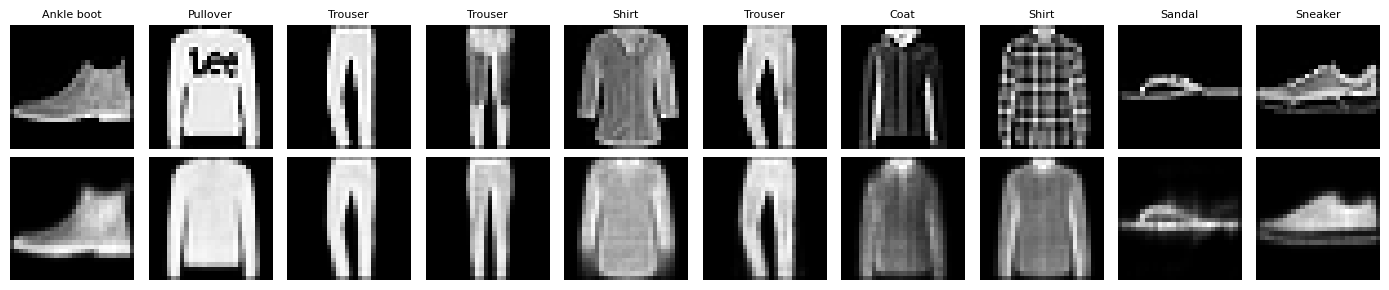

In [11]:
model.eval()
x, labels = next(iter(test_loader))
x = x[:10].to(device)
y = labels_to_onehot(labels[:10]).to(device)

with torch.no_grad():
    recon, _, _ = model(x.view(10, -1), y)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[labels[i]], fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("real")
axes[1, 0].set_ylabel("recon")
plt.tight_layout()
plt.show()

## Generate

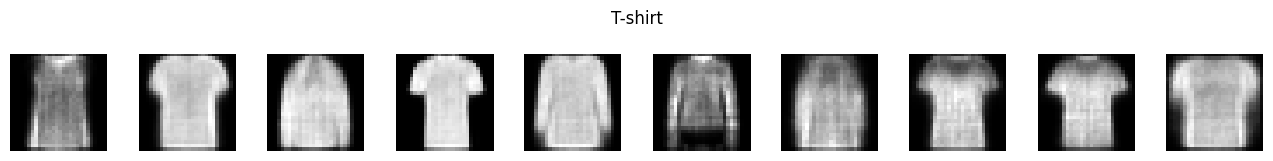

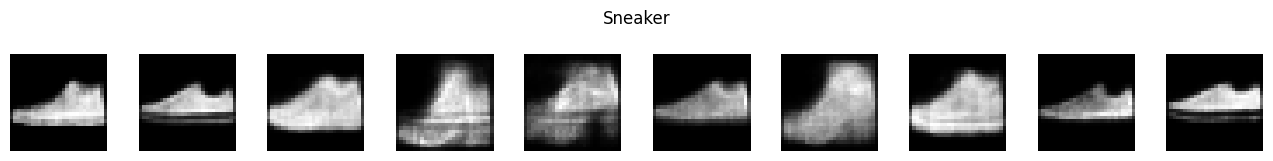

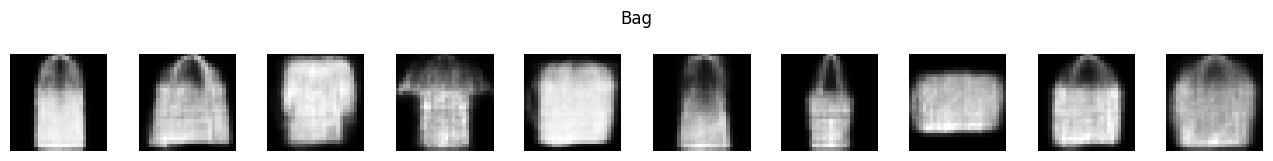

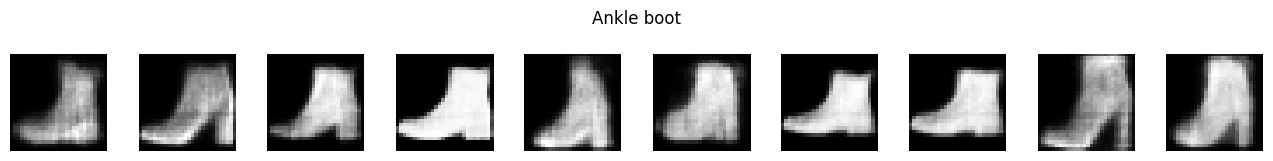

In [12]:
def generate(class_idx, n=10):
    z = torch.randn(n, LATENT_DIM, device=device)
    labels = torch.full((n,), class_idx, dtype=torch.long)
    y = labels_to_onehot(labels).to(device)
    with torch.no_grad():
        return model.decode(z, y).cpu().view(n, 28, 28)


def show_generated(class_idx, n=10):
    imgs = generate(class_idx, n)
    fig, axes = plt.subplots(1, n, figsize=(1.3 * n, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(CLASS_NAMES[class_idx])
    plt.tight_layout()
    plt.show()


for class_idx in [0, 7, 8, 9]:
    show_generated(class_idx)